Â# Learning Curves

**Loss Curve**
- Tends to decrease as epochs go by.
- After a certain amount of epochs, the value converges and we arrive at a minimum.

**Accuracy Curve**
- Tends to increase as epochs go by.
- After a certain amount of epochs, the value converges and we arrive at a maximum.

**Overfitting**
- Plotting training data against validation data can identify overfitting.
- Early stopping callback is useful stop training when test and validation performance curves start to diverge.

**Unstable Curves**
- Many curves will not be smooth, and require tuning hyperparameters like:
    - Selected optimizer
    - Learning rate
    - Batch size
    - Network architecture
    - Weight initialization

**Neural Networks**
- Well known for surpassing traditional machine learning techniques as the size of the dataset is increased.
- Checking whether collecting more data would increase generalization and accuracy may be beneficial.

### Helper functions

In [52]:
def plot_loss(loss,val_loss):
  plt.figure()
  plt.plot(loss)
  plt.plot(val_loss)
  plt.title('Model loss')
  plt.ylabel('Loss')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Test'], loc='upper right')
  plt.show()

def plot_results(train_accs,test_accs):
  plt.plot(training_sizes, train_accs, 'o-', label="Training Accuracy")
  plt.plot(training_sizes, test_accs, 'o-', label="Test Accuracy")
  plt.title('Accuracy vs Number of training samples')
  plt.xlabel('# of training samples')
  plt.ylabel('Accuracy')
  plt.legend(loc="best")
  plt.show()

## Multi-Class Classification with Digits Dataset

### Setup

In [41]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import Input
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load the digits dataset
digits = load_digits()
X, y = digits.data, digits.target

# Split into training and testing sets (30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# One-hot encode the labels using get_dummies and overwrite previous values
y_train = pd.get_dummies(y_train).values
y_test = pd.get_dummies(y_test).values

### Instructions
1. Add a Dense layer of 16 neurons with relu activation and an input_shape that takes the total number of pixels of the 8x8 digit image.
2. Add a Dense layer with 10 outputs and softmax activation.
3. Compile your model with adam, categorical_crossentropy, and accuracy metrics.
4. Make sure your model works by predicting on X_train.

In [47]:
model = Sequential()

model.add(Input(shape=(64,))) # Updated approach to leveraging input_shape
model.add(Dense(16, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

preds = model.predict(X_train)
print(preds)

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 661us/step
[[2.7001431e-02 4.2545926e-02 4.8143171e-05 ... 5.2877126e-04
  7.5292617e-01 1.1598748e-04]
 [5.4723077e-02 8.4611878e-02 9.3207042e-08 ... 9.5483967e-09
  6.8289684e-03 1.5959606e-07]
 [4.5696831e-01 2.6515055e-01 3.1629366e-05 ... 1.7252909e-03
  2.0523284e-01 1.0683992e-03]
 ...
 [3.4856650e-01 5.0700665e-02 3.2307857e-03 ... 3.2669059e-03
  3.7820682e-01 1.5549171e-03]
 [3.4385152e-02 2.3158716e-01 1.3659922e-05 ... 3.4673646e-04
  7.3169208e-01 1.4659093e-05]
 [1.6654144e-01 4.1039443e-01 1.5562381e-04 ... 1.2446100e-04
  3.8369063e-01 1.3229582e-05]]


### Instructions
1. Train your model for 60 epochs, using X_test and y_test as validation data.
2. Use plot_loss() passing loss and val_loss as extracted from the history attribute of the h_callback object.

Epoch 1/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0759 - loss: 6.4222 - val_accuracy: 0.1537 - val_loss: 3.3004
Epoch 2/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1796 - loss: 3.0094 - val_accuracy: 0.3111 - val_loss: 2.1007
Epoch 3/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3362 - loss: 1.9744 - val_accuracy: 0.4111 - val_loss: 1.7086
Epoch 4/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4178 - loss: 1.6861 - val_accuracy: 0.4907 - val_loss: 1.4832
Epoch 5/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5179 - loss: 1.4215 - val_accuracy: 0.5648 - val_loss: 1.3027
Epoch 6/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5867 - loss: 1.1753 - val_accuracy: 0.6111 - val_loss: 1.1524
Epoch 7/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6267 - loss: 1.0542 - val_accuracy: 0.6389 - val_loss: 0.9890
Epoch 8/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7110 - loss: 0.8802 - val_accuracy: 0.7037 - val_loss:

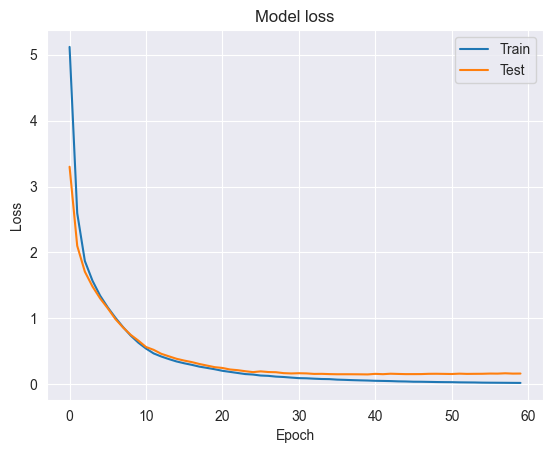

In [48]:
h_callback = model.fit(X_train, y_train, epochs=60, validation_data=(X_test, y_test))
plot_loss(h_callback.history['loss'], h_callback.history['val_loss'])

The above chart shows that as each epoch passes, test loss continues to minimize, indicating that the model is not overfit.

### Assess whether more training is beneficial

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0134 
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0133 
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0107
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0100 
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0092 
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0088 
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0078
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0077 
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0056 
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0061
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0063
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0051 
Epoch

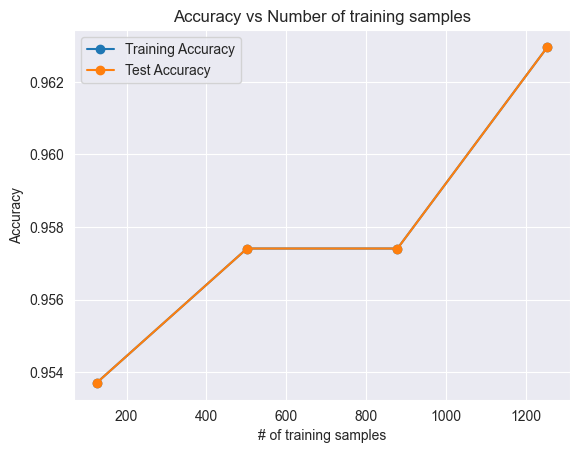

In [51]:
initial_weights = model.get_weights()
training_sizes = [125, 502, 879, 1255]
early_stop = EarlyStopping(monitor='loss', patience=1, restore_best_weights=False)
train_accs = []
test_accs = []

for size in training_sizes:
  # Get a fraction of training data
  X_train_frac, y_train_frac = X_train[:size], y_train[:size]

  # Reset the model to the initial weights and train it on the new training data fraction
  model.set_weights(initial_weights)
  model.fit(X_train_frac, y_train_frac, epochs = 50, callbacks = [early_stop])

  # Evaluate and store both: the training data fraction and the complete test set results
  train_accs.append(model.evaluate(X_test, y_test)[1])
  test_accs.append(model.evaluate(X_test, y_test)[1])

plot_results(train_accs, test_accs)